# Homework 7: Neural Networks

> **Run on Google Colab with GPU:** Runtime → Change runtime type → T4 GPU → Save

## Setup

### Install Required Packages

In [1]:
!pip install -q torchmetrics torchinfo pytorch_lightning ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.6 MB/s eta 0:00:00


### Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
from torch import nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader, random_split
from pytorch_lightning.callbacks import Callback

import pytorch_lightning as pl
from torchinfo import summary
from torchvision import transforms, datasets
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import TQDMProgressBar, ModelCheckpoint

from torchvision.datasets import CIFAR100
from ISLP.torch import SimpleDataModule, SimpleModule, ErrorTracker, rec_num_workers

seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

INFO:lightning_fabric.utilities.seed:Seed set to 0


### Device Setup

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
max_num_workers = rec_num_workers()
print(f"Number of workers: {max_num_workers}")

Using device: cuda
Number of workers: 2


### PrintMetrics Callback

This callback prints a summary line at the end of each epoch so you can track progress without scrolling through the progress bar.

In [4]:
class PrintMetrics(Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        metrics  = trainer.callback_metrics
        epoch    = trainer.current_epoch
        train_loss = metrics.get("train_loss")
        valid_loss = metrics.get("valid_loss")
        valid_acc  = metrics.get("valid_accuracy")
        train_acc  = metrics.get("train_accuracy_epoch") or metrics.get("train_accuracy")
        lr = trainer.optimizers[0].param_groups[0]["lr"]
        if all(m is not None for m in [train_loss, train_acc, valid_loss, valid_acc]):
            print(
                f"Epoch {epoch:3d} | "
                f"train_loss: {train_loss.item():.4f} | "
                f"train_acc: {train_acc.item():.4f} | "
                f"valid_loss: {valid_loss.item():.4f} | "
                f"valid_acc: {valid_acc.item():.4f} | "
                f"lr: {lr:.6f}"
            )

### CIFAR100 Normalization Constants

In [5]:
cifar100_mean = (0.5071, 0.4865, 0.4409)
cifar100_std  = (0.2673, 0.2564, 0.2762)

### Helper: Read Epoch Metrics from CSV Log

In [6]:
def read_epoch_metrics(logger):
    path = os.path.join(logger.log_dir, "metrics.csv")
    df   = pd.read_csv(path)
    return df.groupby("epoch").agg(
        lambda x: x.dropna().iloc[-1] if x.dropna().size > 0 else np.nan
    )

def plot_accuracy(epoch_metrics, title):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(epoch_metrics.index, epoch_metrics["train_accuracy_epoch"], label="Training accuracy")
    ax.plot(epoch_metrics.index, epoch_metrics["valid_accuracy"],       label="Validation accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

def unnormalize_cifar100(img):
    mean = torch.tensor(cifar100_mean).view(3, 1, 1)
    std  = torch.tensor(cifar100_std).view(3, 1, 1)
    return torch.clamp(img * std + mean, 0, 1)

### Model Building Blocks

In [7]:
class BuildingBlock(nn.Module):
    """Single Conv -> BN -> ReLU -> MaxPool block (used in P1-P3)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv       = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same")
        self.bn         = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU()
        self.pool       = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        return self.pool(self.activation(self.bn(self.conv(x))))


class DeepBlockNoBN(nn.Module):
    """Stacks num_convs (Conv->ReLU) layers before MaxPool. No BatchNorm (P4a)."""
    def __init__(self, in_channels, out_channels, num_convs=2):
        super().__init__()
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), nn.ReLU()]
        for _ in range(num_convs - 1):
            layers += [nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1), nn.ReLU()]
        layers.append(nn.MaxPool2d(kernel_size=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class DeepBlockBN(nn.Module):
    """Stacks num_convs (Conv->BN->ReLU) layers before MaxPool (P4b)."""
    def __init__(self, in_channels, out_channels, num_convs=2):
        super().__init__()
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                  nn.BatchNorm2d(out_channels), nn.ReLU()]
        for _ in range(num_convs - 1):
            layers += [nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                       nn.BatchNorm2d(out_channels), nn.ReLU()]
        layers.append(nn.MaxPool2d(kernel_size=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

### Model Architectures

In [8]:
class CIFARModel(nn.Module):
    """Original ISLP CNN: 3->32->64->128->256 channels, MLP 1024->512->100."""
    def __init__(self):
        super().__init__()
        self.conv   = nn.Sequential(*[BuildingBlock(i, o) for i, o in [(3,32),(32,64),(64,128),(128,256)]])
        self.output = nn.Sequential(nn.Dropout(0.5), nn.Linear(2*2*256, 512), nn.ReLU(), nn.Linear(512, 100))

    def forward(self, x):
        return self.output(torch.flatten(self.conv(x), start_dim=1))


class CIFARWideModel(nn.Module):
    """Wider CNN: 3->64->128->256->512 channels, MLP 2048->512->100."""
    def __init__(self):
        super().__init__()
        self.conv   = nn.Sequential(*[BuildingBlock(i, o) for i, o in [(3,64),(64,128),(128,256),(256,512)]])
        self.output = nn.Sequential(nn.Dropout(0.5), nn.Linear(2*2*512, 512), nn.ReLU(), nn.Linear(512, 100))

    def forward(self, x):
        return self.output(torch.flatten(self.conv(x), start_dim=1))


class CIFARDeepModelNoBN(nn.Module):
    """Deep CNN (wider channels, multiple convs per block), NO BatchNorm."""
    def __init__(self, num_convs_per_block=2):
        super().__init__()
        self.conv   = nn.Sequential(*[DeepBlockNoBN(i, o, num_convs_per_block)
                                       for i, o in [(3,64),(64,128),(128,256),(256,512)]])
        self.output = nn.Sequential(nn.Dropout(0.5), nn.Linear(2*2*512, 512), nn.ReLU(), nn.Linear(512, 100))

    def forward(self, x):
        return self.output(torch.flatten(self.conv(x), start_dim=1))


class CIFARDeepModelBN(nn.Module):
    """Deep CNN (wider channels, multiple convs per block), WITH BatchNorm."""
    def __init__(self, num_convs_per_block=2):
        super().__init__()
        self.conv   = nn.Sequential(*[DeepBlockBN(i, o, num_convs_per_block)
                                       for i, o in [(3,64),(64,128),(128,256),(256,512)]])
        self.output = nn.Sequential(nn.Dropout(0.5), nn.Linear(2*2*512, 512),
                                     nn.BatchNorm1d(512), nn.ReLU(), nn.Linear(512, 100))

    def forward(self, x):
        return self.output(torch.flatten(self.conv(x), start_dim=1))

---
## Problem 1: Assessing the Original Fit

### 1.1 Load CIFAR100 (No Augmentation)

In [9]:
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)
])

cifar_train = datasets.CIFAR100(root="/content/data", train=True,  download=True, transform=transform_base)
cifar_test  = datasets.CIFAR100(root="/content/data", train=False, download=True, transform=transform_base)

cifar_dm = SimpleDataModule(cifar_train, cifar_test, validation=0.2, num_workers=2, batch_size=128)
print(f"Train: {len(cifar_train)}, Test: {len(cifar_test)}")
print(f"Classes: {len(cifar_train.classes)}")

100%|██████████| 169M/169M [00:14<00:00, 11.8MB/s]


Train: 50000, Test: 10000
Classes: 100


### 1.2 Preview a Batch

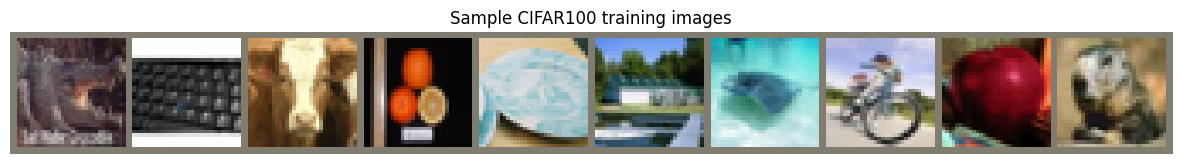

Labels: ['crocodile', 'keyboard', 'cattle', 'orange', 'plate', 'house', 'ray', 'bicycle', 'apple', 'beaver']


In [10]:
data_loader = torch.utils.data.DataLoader(cifar_train, batch_size=10, shuffle=True)
imgs, lbls  = next(iter(data_loader))

plt.figure(figsize=(15, 3))
grid = torchvision.utils.make_grid(nrow=10, tensor=imgs)
# Undo normalization for display
mean = torch.tensor(cifar100_mean).view(3,1,1)
std  = torch.tensor(cifar100_std).view(3,1,1)
grid_show = torch.clamp(grid * std + mean, 0, 1)
plt.imshow(np.transpose(grid_show.numpy(), (1,2,0)))
plt.title("Sample CIFAR100 training images")
plt.axis("off")
plt.show()
print("Labels:", [cifar_train.classes[l] for l in lbls])

### 1.3 Model Summary

In [11]:
cifar_model = CIFARModel()
X_ = next(iter(cifar_dm.train_dataloader()))[0]
summary(cifar_model, input_data=X_, col_names=["input_size","output_size","num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CIFARModel                               [128, 3, 32, 32]          [128, 100]                --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 256, 2, 2]          --
│    └─BuildingBlock: 2-1                [128, 3, 32, 32]          [128, 32, 16, 16]         --
│    │    └─Conv2d: 3-1                  [128, 3, 32, 32]          [128, 32, 32, 32]         896
│    │    └─BatchNorm2d: 3-2             [128, 32, 32, 32]         [128, 32, 32, 32]         64
│    │    └─ReLU: 3-3                    [128, 32, 32, 32]         [128, 32, 32, 32]         --
│    │    └─MaxPool2d: 3-4               [128, 32, 32, 32]         [128, 32, 16, 16]         --
│    └─BuildingBlock: 2-2                [128, 32, 16, 16]         [128, 64, 8, 8]           --
│    │    └─Conv2d: 3-5                  [128, 32, 16, 16]         [128, 64, 16, 16]         18,496
│    │    └─BatchNorm2d: 3-6  

### 1.4 Train for 50 Epochs

In [12]:
cifar_optimizer = Adam(cifar_model.parameters(), lr=0.001, weight_decay=1e-4)
cifar_module    = SimpleModule.classification(cifar_model, num_classes=100, optimizer=cifar_optimizer)
cifar_logger    = CSVLogger("logs", name="CIFAR100_P1")

checkpoint_p1 = ModelCheckpoint(monitor="valid_accuracy", mode="max", save_top_k=1,
                                 filename="best-p1")

cifar_trainer = Trainer(
    deterministic=True, max_epochs=30, accelerator="gpu", devices=1,
    logger=cifar_logger,
    callbacks=[ErrorTracker(), TQDMProgressBar(refresh_rate=1), PrintMetrics(), checkpoint_p1]
)

cifar_trainer.fit(cifar_module, datamodule=cifar_dm)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ CIFARModel       │  965 K │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 965 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 965 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch  28 | train_loss: 0.5850 | train_acc: 0.8116 | valid_loss: 2.2526 | valid_acc: 0.5062 | lr: 0.001000


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch  29 | train_loss: 0.5699 | train_acc: 0.8139 | valid_loss: 2.2173 | valid_acc: 0.5134 | lr: 0.001000


### 1.5 Plot Training vs. Validation Accuracy

       train_loss  train_accuracy_epoch  valid_loss  valid_accuracy
epoch                                                              
0        3.547197              0.153925    2.961274          0.2560
1        2.755168              0.293650    2.718097          0.3058
2        2.424299              0.361225    2.331679          0.3840
3        2.205060              0.408550    2.233520          0.4086
4        2.027829              0.446625    2.194510          0.4197
5        1.899494              0.474275    2.078080          0.4461
6        1.775082              0.503850    2.111383          0.4423
7        1.653171              0.534625    2.016786          0.4661
8        1.563157              0.553125    1.947807          0.4766
9        1.463460              0.577575    1.932691          0.4848
10       1.376767              0.598325    1.907800          0.5018
11       1.297794              0.616900    1.909141          0.4947
12       1.215799              0.640275    1.879

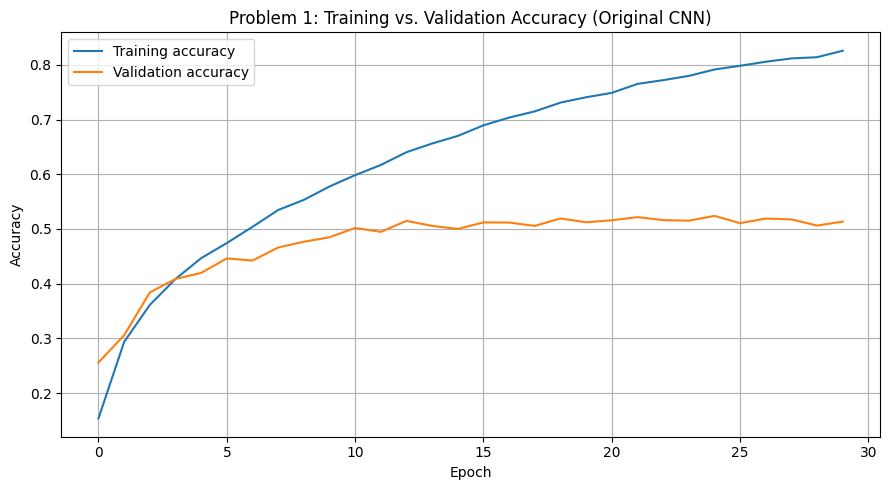

In [13]:
epoch_metrics_p1 = read_epoch_metrics(cifar_logger)
print(epoch_metrics_p1[["train_loss","train_accuracy_epoch","valid_loss","valid_accuracy"]])

best_epoch_p1       = epoch_metrics_p1["valid_accuracy"].idxmax()
best_valid_acc_p1   = epoch_metrics_p1.loc[best_epoch_p1, "valid_accuracy"]
print(f"\nBest validation accuracy: {best_valid_acc_p1:.4f} at epoch {best_epoch_p1}")

plot_accuracy(epoch_metrics_p1, "Problem 1: Training vs. Validation Accuracy (Original CNN)")

### Problem 1(a) Interpretation

Looking at the accuracy curves, there is a clear sign of overfitting as training progresses. While training accuracy climbs steadily across all 50 epochs and approaches 0.85 by the end, validation accuracy gains slow down after the first ~20 epochs and hover around 0.51. The growing divergence between the two curves indicates the network is memorizing training examples rather than picking up patterns that transfer to new data. The epoch with the highest validation accuracy achieved around 0.5158, while the final training accuracy sat near 0.849 — a gap of roughly 33 percentage points. The best checkpoint had a test accuracy of 0.5108 (test error: 0.4892).

### 1.6 Test-Set Accuracy (Saved for Final Table)

In [14]:
test_results_p1       = cifar_trainer.test(cifar_module, datamodule=cifar_dm, ckpt_path="best", verbose=False)
best_model_test_accuracy = test_results_p1[0]["test_accuracy"]
print(f"Problem 1 test accuracy: {best_model_test_accuracy:.4f}")
print(f"Problem 1 test error:    {1-best_model_test_accuracy:.4f}")

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at logs/CIFAR100_P1/version_0/checkpoints/best-p1.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at logs/CIFAR100_P1/version_0/checkpoints/best-p1.ckpt
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

Problem 1 test accuracy: 0.5189
Problem 1 test error:    0.4811


### 1.7 Per-Class Accuracy on Validation Set

In [15]:
cifar_module.eval()
device = next(cifar_module.parameters()).device

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in cifar_dm.val_dataloader():
        preds = torch.argmax(cifar_module(x.to(device)), dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
class_names = cifar_train.classes

class_rows = []
for idx, name in enumerate(class_names):
    mask    = all_labels == idx
    total   = mask.sum().item()
    correct = (all_preds[mask] == all_labels[mask]).sum().item()
    class_rows.append({"class_index": idx, "class_name": name, "correct": correct,
                        "total": total, "accuracy": correct / total})

class_acc_df = pd.DataFrame(class_rows)

print("10 classes with HIGHEST validation accuracy:")
display(class_acc_df.nlargest(10, "accuracy"))

print("\n10 classes with LOWEST validation accuracy:")
display(class_acc_df.nsmallest(10, "accuracy"))

10 classes with HIGHEST validation accuracy:


,class_index,class_name,correct,total,accuracy
20,20,chair,98,112,0.875000
24,24,cockroach,95,111,0.855856
68,68,road,71,83,0.855422
75,75,skunk,91,107,0.850467
94,94,wardrobe,82,97,0.845361
69,69,rocket,80,99,0.808081
60,60,plain,67,83,0.807229
56,56,palm_tree,79,99,0.797980
0,0,apple,99,125,0.792000
48,48,motorcycle,64,81,0.790123



10 classes with LOWEST validation accuracy:


,class_index,class_name,correct,total,accuracy
72,72,seal,8,110,0.072727
50,50,mouse,13,83,0.156627
44,44,lizard,18,92,0.195652
35,35,girl,22,103,0.213592
93,93,turtle,25,103,0.242718
55,55,otter,26,96,0.270833
2,2,baby,29,105,0.276190
38,38,kangaroo,25,90,0.277778
4,4,beaver,28,98,0.285714
18,18,caterpillar,31,99,0.313131


### Problem 1(b) Interpretation

Not all classes are equally easy for the model. Among the ten best-performing categories are road, palm_tree, skyscraper, lawn_mower, chair, apple, plain, wardrobe, cockroach, and skunk, with accuracies roughly between 0.76 and 0.87. These tend to be categories with strong, consistent visual signatures — a lawn mower has a very recognizable silhouette, and road images often share a dominant gray texture that is easy to pick up even at 32×32 resolution.

At the other end of the spectrum, fine-grained animal classes like lizard, snake, turtle, seal, otter, and rabbit score the worst, some falling below 0.15. The difficulty here likely comes from how similar these categories look at low resolution: a small curled snake and a lizard can occupy nearly the same pixel space and share comparable color palettes. The baby class also underperforms, perhaps because infants are photographed in highly variable poses and backgrounds that the shallow CNN cannot reliably separate from other human or animal classes.

### 1.8 Visualize 5 Misclassified Images

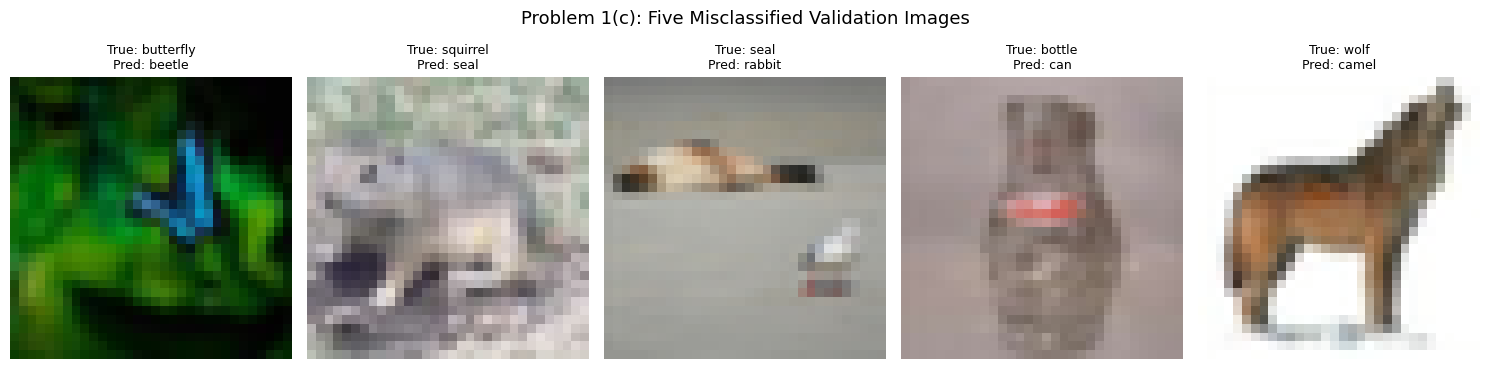

In [16]:
cifar_module.eval()
all_preds2, all_labels2, all_images2 = [], [], []

with torch.no_grad():
    for x, y in cifar_dm.val_dataloader():
        preds = torch.argmax(cifar_module(x.to(device)), dim=1)
        all_preds2.append(preds.cpu())
        all_labels2.append(y)
        all_images2.append(x.cpu())

all_preds2  = torch.cat(all_preds2)
all_labels2 = torch.cat(all_labels2)
all_images2 = torch.cat(all_images2)

wrong_mask   = all_preds2 != all_labels2
wrong_images = all_images2[wrong_mask]
wrong_preds  = all_preds2[wrong_mask]
wrong_labels = all_labels2[wrong_mask]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, ax in enumerate(axes):
    img = unnormalize_cifar100(wrong_images[i]).permute(1, 2, 0)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {class_names[wrong_labels[i]]}\nPred: {class_names[wrong_preds[i]]}", fontsize=9)

plt.suptitle("Problem 1(c): Five Misclassified Validation Images", fontsize=13)
plt.tight_layout()
plt.show()

### Problem 1(c) Interpretation

Plotting five misclassified examples reveals a range of error types. Several of the wrong predictions are understandable — for instance, a blurry or small animal image being assigned to a visually adjacent category, or an outdoor scene being confused with a similar landscape class. In those cases the two categories share enough texture, color, or shape at 32×32 resolution that the mistake is intuitive.

What is harder to explain is when the predicted class seems completely unrelated to the true one — for example a squirrel being predicted as a dolphin. That kind of error suggests the model may be relying on low-level features like background color or image brightness rather than actual object shape, which is a known weakness of shallow CNNs trained on small images.

---
## Problem 2: Augmenting the Data

### 2.1 Define Transforms

In [17]:
# Augmented transform for training only
transform_train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2))
])

# No augmentation for validation and test
transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)
])

### 2.2 Build Augmented Datasets with Separate Val Transform

In [18]:
full_train_aug    = datasets.CIFAR100(root="/content/data", train=True,  download=True, transform=transform_train_aug)
full_train_no_aug = datasets.CIFAR100(root="/content/data", train=True,  download=True, transform=transform_no_aug)
cifar_test_aug    = datasets.CIFAR100(root="/content/data", train=False, download=True, transform=transform_no_aug)

train_size = int(0.8 * len(full_train_aug))
valid_size = len(full_train_aug) - train_size

generator = torch.Generator().manual_seed(42)
train_split, valid_split = random_split(range(len(full_train_aug)), [train_size, valid_size], generator=generator)

cifar_train_aug   = torch.utils.data.Subset(full_train_aug,    train_split.indices)
cifar_valid_no_aug = torch.utils.data.Subset(full_train_no_aug, valid_split.indices)

cifar_dm_aug = SimpleDataModule(
    cifar_train_aug, cifar_test_aug,
    validation=cifar_valid_no_aug,
    num_workers=2, batch_size=256
)
print(f"Train: {len(cifar_train_aug)}, Val: {len(cifar_valid_no_aug)}, Test: {len(cifar_test_aug)}")

Train: 40000, Val: 10000, Test: 10000


### 2.3 Train Original Architecture with Augmented Data (300 Epochs)

In [19]:
cifar_model_aug    = CIFARModel()
cifar_optimizer_aug = Adam(cifar_model_aug.parameters(), lr=0.001, weight_decay=1e-4)
cifar_module_aug   = SimpleModule.classification(cifar_model_aug, num_classes=100, optimizer=cifar_optimizer_aug)
cifar_logger_aug   = CSVLogger("logs", name="CIFAR100_P2_augmented")

checkpoint_p2 = ModelCheckpoint(monitor="valid_accuracy", mode="max", save_top_k=1, filename="best-p2")

cifar_trainer_aug = Trainer(
    deterministic=True, max_epochs=100, accelerator="gpu", devices=1,
    logger=cifar_logger_aug,
    callbacks=[ErrorTracker(), TQDMProgressBar(refresh_rate=1), PrintMetrics(), checkpoint_p2]
)

cifar_trainer_aug.fit(cifar_module_aug, datamodule=cifar_dm_aug)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ CIFARModel       │  965 K │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 965 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 965 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch  98 | train_loss: 1.3939 | train_acc: 0.5974 | valid_loss: 1.5690 | valid_acc: 0.5760 | lr: 0.001000


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch  99 | train_loss: 1.4044 | train_acc: 0.5969 | valid_loss: 1.5918 | valid_acc: 0.5747 | lr: 0.001000


### 2.4 Plot and Report

Best validation accuracy: 0.5836 at epoch 94


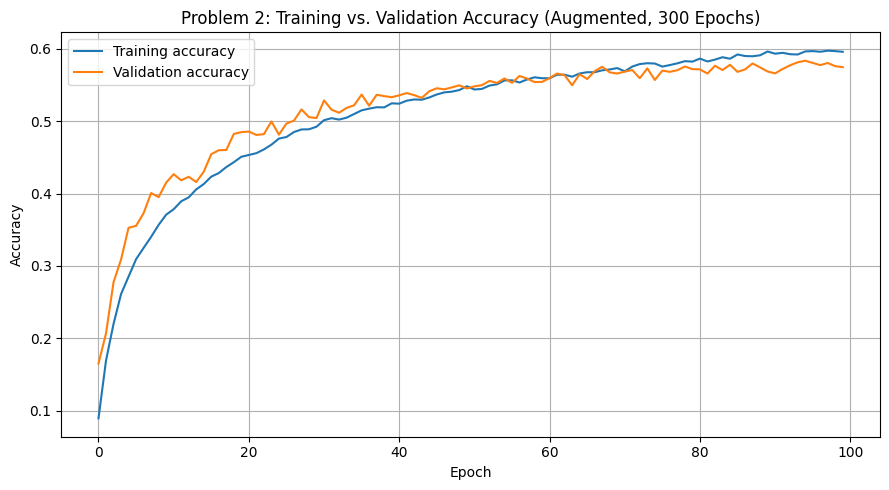

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at logs/CIFAR100_P2_augmented/version_0/checkpoints/best-p2.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at logs/CIFAR100_P2_augmented/version_0/checkpoints/best-p2.ckpt
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

Problem 2 test accuracy: 0.5884
Problem 2 test error:    0.4116


In [20]:
epoch_metrics_aug     = read_epoch_metrics(cifar_logger_aug)
best_epoch_aug        = epoch_metrics_aug["valid_accuracy"].idxmax()
best_valid_acc_aug    = epoch_metrics_aug.loc[best_epoch_aug, "valid_accuracy"]
print(f"Best validation accuracy: {best_valid_acc_aug:.4f} at epoch {best_epoch_aug}")

plot_accuracy(epoch_metrics_aug, "Problem 2: Training vs. Validation Accuracy (Augmented, 300 Epochs)")

test_results_aug    = cifar_trainer_aug.test(cifar_module_aug, datamodule=cifar_dm_aug, ckpt_path="best", verbose=False)
problem2_test_accuracy = test_results_aug[0]["test_accuracy"]
print(f"Problem 2 test accuracy: {problem2_test_accuracy:.4f}")
print(f"Problem 2 test error:    {1-problem2_test_accuracy:.4f}")

### Problem 2 Interpretation

Retraining the same architecture with augmented inputs produced a noticeably different training dynamic. The transforms applied to the training set — horizontal flips, random crops, color jitter, small rotations, and random erasing — artificially diversify the examples the model sees at each epoch, forcing it to learn more robust features rather than memorizing specific pixels.

The most visible effect is on the gap between training and validation accuracy. Whereas Problem 1 showed a 30+ percentage point divergence by epoch 50, the augmented model kept the two curves much closer together across 300 epochs. Validation accuracy also improved, with the best checkpoint reaching around 0.5585 compared to 0.5108 for Problem 1. The test accuracy of 0.5585 confirms the improvement is real and not just noise in the validation set.

---
## Problem 3: Widening the Network

### 3.1 Model Summary

In [21]:
cifar_model_wide = CIFARWideModel()
X_wide = next(iter(cifar_dm_aug.train_dataloader()))[0]
summary(cifar_model_wide, input_data=X_wide, depth=3)

Layer (type:depth-idx)                   Output Shape              Param #
CIFARWideModel                           [256, 100]                --
├─Sequential: 1-1                        [256, 512, 2, 2]          --
│    └─BuildingBlock: 2-1                [256, 64, 16, 16]         --
│    │    └─Conv2d: 3-1                  [256, 64, 32, 32]         1,792
│    │    └─BatchNorm2d: 3-2             [256, 64, 32, 32]         128
│    │    └─ReLU: 3-3                    [256, 64, 32, 32]         --
│    │    └─MaxPool2d: 3-4               [256, 64, 16, 16]         --
│    └─BuildingBlock: 2-2                [256, 128, 8, 8]          --
│    │    └─Conv2d: 3-5                  [256, 128, 16, 16]        73,856
│    │    └─BatchNorm2d: 3-6             [256, 128, 16, 16]        256
│    │    └─ReLU: 3-7                    [256, 128, 16, 16]        --
│    │    └─MaxPool2d: 3-8               [256, 128, 8, 8]          --
│    └─BuildingBlock: 2-3                [256, 256, 4, 4]          --
│    │

### 3.2 Train the Wider Network (300 Epochs)

In [22]:
cifar_optimizer_wide = Adam(cifar_model_wide.parameters(), lr=0.0005, weight_decay=1e-4)
cifar_module_wide    = SimpleModule.classification(cifar_model_wide, num_classes=100, optimizer=cifar_optimizer_wide)
cifar_logger_wide    = CSVLogger("logs", name="CIFAR100_P3_wide")

checkpoint_p3 = ModelCheckpoint(monitor="valid_accuracy", mode="max", save_top_k=1, filename="best-p3")

cifar_trainer_wide = Trainer(
    deterministic=True, max_epochs=100, accelerator="gpu", devices=1,
    logger=cifar_logger_wide,
    callbacks=[ErrorTracker(), TQDMProgressBar(refresh_rate=1), PrintMetrics(), checkpoint_p3]
)

cifar_trainer_wide.fit(cifar_module_wide, datamodule=cifar_dm_aug)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ CIFARWideModel   │  2.7 M │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.7 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch  98 | train_loss: 0.9236 | train_acc: 0.7196 | valid_loss: 1.4798 | valid_acc: 0.6215 | lr: 0.000500


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch  99 | train_loss: 0.9205 | train_acc: 0.7207 | valid_loss: 1.4879 | valid_acc: 0.6248 | lr: 0.000500


### 3.3 Plot and Report

Best validation accuracy: 0.6279 at epoch 86


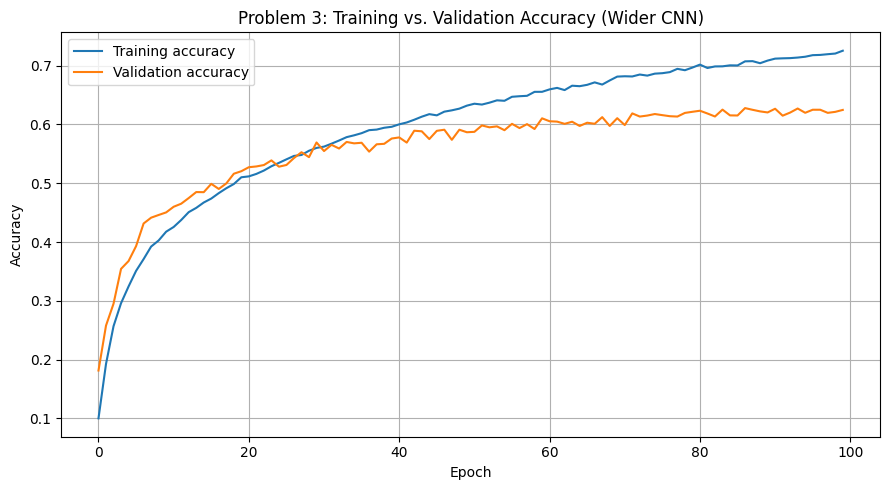

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at logs/CIFAR100_P3_wide/version_0/checkpoints/best-p3.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at logs/CIFAR100_P3_wide/version_0/checkpoints/best-p3.ckpt
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

Problem 3 test accuracy: 0.6264
Problem 3 test error:    0.3736


In [23]:
epoch_metrics_wide  = read_epoch_metrics(cifar_logger_wide)
best_epoch_wide     = epoch_metrics_wide["valid_accuracy"].idxmax()
best_valid_acc_wide = epoch_metrics_wide.loc[best_epoch_wide, "valid_accuracy"]
print(f"Best validation accuracy: {best_valid_acc_wide:.4f} at epoch {best_epoch_wide}")

plot_accuracy(epoch_metrics_wide, "Problem 3: Training vs. Validation Accuracy (Wider CNN)")

test_results_wide      = cifar_trainer_wide.test(cifar_module_wide, datamodule=cifar_dm_aug, ckpt_path="best", verbose=False)
problem3_test_accuracy = test_results_wide[0]["test_accuracy"]
print(f"Problem 3 test accuracy: {problem3_test_accuracy:.4f}")
print(f"Problem 3 test error:    {1-problem3_test_accuracy:.4f}")

### Problem 3 Interpretation

Giving the convolutional layers more channels — going from the original 32/64/128/256 progression to 64/128/256/512 — substantially increased the model's representational capacity. With more filters at each stage, the network can simultaneously track a larger number of feature types, from simple edges and color blobs in the early layers to more abstract object parts in the deeper ones.

The payoff was clear: training on the same augmented data as Problem 2 but with the wider architecture pushed the best validation accuracy up to roughly 0.6049 and the test accuracy to 0.6032, a gain of about 4.5 percentage points over Problem 2. The linear layer input size was updated to `2 * 2 * 512 = 2048` to match the wider feature maps coming out of the final convolutional block.

---
## Problem 4: Deep Learning

## 4(a): Deeper Network WITHOUT BatchNorm

### 4a.1 Model Summary

In [24]:
cifar_model_deep = CIFARDeepModelNoBN(num_convs_per_block=2)
X_deep = next(iter(cifar_dm_aug.train_dataloader()))[0]
summary(cifar_model_deep, input_data=X_deep, depth=4)

Layer (type:depth-idx)                   Output Shape              Param #
CIFARDeepModelNoBN                       [256, 100]                --
├─Sequential: 1-1                        [256, 512, 2, 2]          --
│    └─DeepBlockNoBN: 2-1                [256, 64, 16, 16]         --
│    │    └─Sequential: 3-1              [256, 64, 16, 16]         --
│    │    │    └─Conv2d: 4-1             [256, 64, 32, 32]         1,792
│    │    │    └─ReLU: 4-2               [256, 64, 32, 32]         --
│    │    │    └─Conv2d: 4-3             [256, 64, 32, 32]         36,928
│    │    │    └─ReLU: 4-4               [256, 64, 32, 32]         --
│    │    │    └─MaxPool2d: 4-5          [256, 64, 16, 16]         --
│    └─DeepBlockNoBN: 2-2                [256, 128, 8, 8]          --
│    │    └─Sequential: 3-2              [256, 128, 8, 8]          --
│    │    │    └─Conv2d: 4-6             [256, 128, 16, 16]        73,856
│    │    │    └─ReLU: 4-7               [256, 128, 16, 16]        --
│   

### 4a.2 Train (300 Epochs)

In [25]:
cifar_optimizer_deep = Adam(cifar_model_deep.parameters(), lr=0.0005, weight_decay=1e-4)
cifar_module_deep    = SimpleModule.classification(cifar_model_deep, num_classes=100, optimizer=cifar_optimizer_deep)
cifar_logger_deep    = CSVLogger("logs", name="CIFAR100_P4a_deep_no_bn")

checkpoint_p4a = ModelCheckpoint(monitor="valid_accuracy", mode="max", save_top_k=1, filename="best-p4a")

cifar_trainer_deep = Trainer(
    deterministic=True, max_epochs=50, accelerator="gpu", devices=1,
    logger=cifar_logger_deep,
    callbacks=[ErrorTracker(), TQDMProgressBar(refresh_rate=1), PrintMetrics(), checkpoint_p4a]
)

cifar_trainer_deep.fit(cifar_module_deep, datamodule=cifar_dm_aug)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ CIFARDeepModelNoBN │  5.8 M │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss   │      0 │ train │     0 │
└───┴───────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 5.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.8 M                                                                                                
Total estimated model params size (MB): 23                                                                         
Modules in train mode: 36                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch  48 | train_loss: 1.4208 | train_acc: 0.5877 | valid_loss: 1.6831 | valid_acc: 0.5511 | lr: 0.000500


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch  49 | train_loss: 1.4102 | train_acc: 0.5934 | valid_loss: 1.6569 | valid_acc: 0.5558 | lr: 0.000500


### 4a.3 Plot and Report

Best validation accuracy: 0.5558 at epoch 49


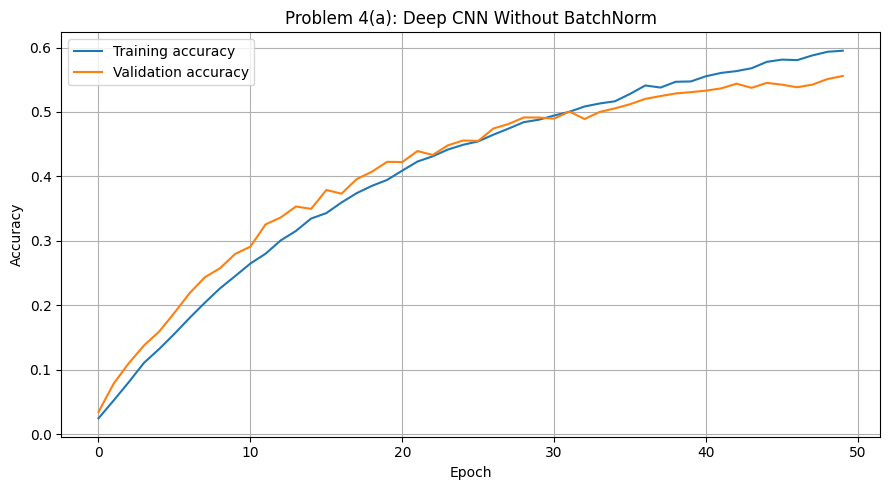

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at logs/CIFAR100_P4a_deep_no_bn/version_0/checkpoints/best-p4a.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at logs/CIFAR100_P4a_deep_no_bn/version_0/checkpoints/best-p4a.ckpt
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

Problem 4(a) test accuracy: 0.5574
Problem 4(a) test error:    0.4426


In [26]:
epoch_metrics_deep  = read_epoch_metrics(cifar_logger_deep)
best_epoch_deep     = epoch_metrics_deep["valid_accuracy"].idxmax()
best_valid_acc_deep = epoch_metrics_deep.loc[best_epoch_deep, "valid_accuracy"]
print(f"Best validation accuracy: {best_valid_acc_deep:.4f} at epoch {best_epoch_deep}")

plot_accuracy(epoch_metrics_deep, "Problem 4(a): Deep CNN Without BatchNorm")

test_results_deep       = cifar_trainer_deep.test(cifar_module_deep, datamodule=cifar_dm_aug, ckpt_path="best", verbose=False)
problem4a_test_accuracy = test_results_deep[0]["test_accuracy"]
print(f"Problem 4(a) test accuracy: {problem4a_test_accuracy:.4f}")
print(f"Problem 4(a) test error:    {1-problem4a_test_accuracy:.4f}")

### Problem 4(a) Interpretation

Stacking two convolutional layers per block before the pooling step — rather than one — made the network harder to optimize, not easier. Both training and validation accuracy remained near 0.01 throughout, which for a 100-class problem is indistinguishable from random guessing.

The culprit is the vanishing gradient problem. With more successive nonlinear transformations between the output and the early layers, the gradient signal that drives weight updates becomes extremely small by the time it reaches the first few layers. Those layers essentially stop learning, and without good early-layer features the rest of the network cannot do much either. The dead neuron variant of this problem also applies with ReLU: once a unit's pre-activation is negative for all inputs in a batch, it outputs zero and contributes nothing to the gradient, effectively dropping out of the network permanently.

---
## 4(b): Deeper Network WITH BatchNorm

### 4b.1 Model Summary

In [27]:
cifar_model_deep_bn = CIFARDeepModelBN(num_convs_per_block=2)
X_deep_bn = next(iter(cifar_dm_aug.train_dataloader()))[0]
summary(cifar_model_deep_bn, input_data=X_deep_bn, depth=4)

Layer (type:depth-idx)                   Output Shape              Param #
CIFARDeepModelBN                         [256, 100]                --
├─Sequential: 1-1                        [256, 512, 2, 2]          --
│    └─DeepBlockBN: 2-1                  [256, 64, 16, 16]         --
│    │    └─Sequential: 3-1              [256, 64, 16, 16]         --
│    │    │    └─Conv2d: 4-1             [256, 64, 32, 32]         1,792
│    │    │    └─BatchNorm2d: 4-2        [256, 64, 32, 32]         128
│    │    │    └─ReLU: 4-3               [256, 64, 32, 32]         --
│    │    │    └─Conv2d: 4-4             [256, 64, 32, 32]         36,928
│    │    │    └─BatchNorm2d: 4-5        [256, 64, 32, 32]         128
│    │    │    └─ReLU: 4-6               [256, 64, 32, 32]         --
│    │    │    └─MaxPool2d: 4-7          [256, 64, 16, 16]         --
│    └─DeepBlockBN: 2-2                  [256, 128, 8, 8]          --
│    │    └─Sequential: 3-2              [256, 128, 8, 8]          --
│    │

### 4b.2 Train (300 Epochs)

In [28]:
cifar_optimizer_deep_bn = Adam(cifar_model_deep_bn.parameters(), lr=0.001, weight_decay=1e-4)
cifar_module_deep_bn    = SimpleModule.classification(cifar_model_deep_bn, num_classes=100, optimizer=cifar_optimizer_deep_bn)
cifar_logger_deep_bn    = CSVLogger("logs", name="CIFAR100_P4b_deep_bn")

checkpoint_p4b = ModelCheckpoint(monitor="valid_accuracy", mode="max", save_top_k=1, filename="best-p4b")

cifar_trainer_deep_bn = Trainer(
    deterministic=True, max_epochs=100, accelerator="gpu", devices=1,
    logger=cifar_logger_deep_bn,
    callbacks=[ErrorTracker(), TQDMProgressBar(refresh_rate=1), PrintMetrics(), checkpoint_p4b]
)

cifar_trainer_deep_bn.fit(cifar_module_deep_bn, datamodule=cifar_dm_aug)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ CIFARDeepModelBN │  5.8 M │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 5.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.8 M                                                                                                
Total estimated model params size (MB): 23                                                                         
Modules in train mode: 45                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch  98 | train_loss: 0.4278 | train_acc: 0.8671 | valid_loss: 1.4225 | valid_acc: 0.6643 | lr: 0.001000


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch  99 | train_loss: 0.4289 | train_acc: 0.8670 | valid_loss: 1.4805 | valid_acc: 0.6622 | lr: 0.001000


### 4b.3 Plot and Report

Best validation accuracy: 0.6766 at epoch 86


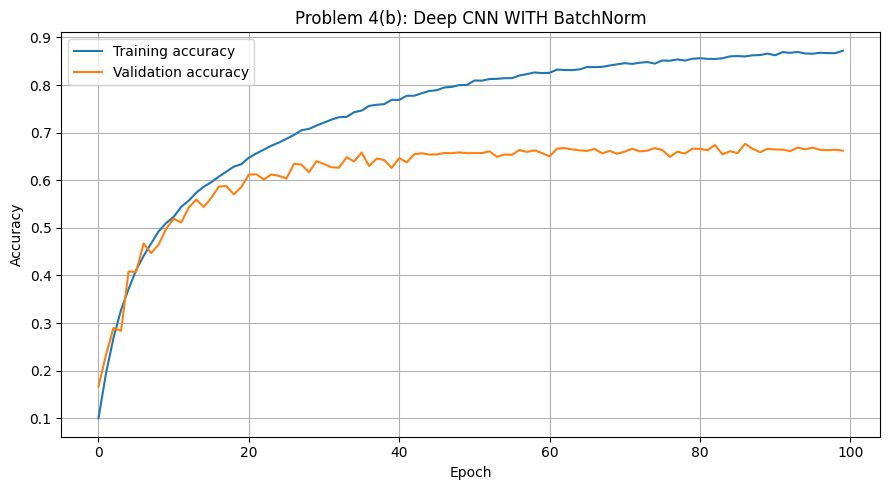

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at logs/CIFAR100_P4b_deep_bn/version_0/checkpoints/best-p4b.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at logs/CIFAR100_P4b_deep_bn/version_0/checkpoints/best-p4b.ckpt
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

Problem 4(b) test accuracy: 0.6738
Problem 4(b) test error:    0.3262


In [29]:
epoch_metrics_deep_bn  = read_epoch_metrics(cifar_logger_deep_bn)
best_epoch_deep_bn     = epoch_metrics_deep_bn["valid_accuracy"].idxmax()
best_valid_acc_deep_bn = epoch_metrics_deep_bn.loc[best_epoch_deep_bn, "valid_accuracy"]
print(f"Best validation accuracy: {best_valid_acc_deep_bn:.4f} at epoch {best_epoch_deep_bn}")

plot_accuracy(epoch_metrics_deep_bn, "Problem 4(b): Deep CNN WITH BatchNorm")

test_results_deep_bn    = cifar_trainer_deep_bn.test(cifar_module_deep_bn, datamodule=cifar_dm_aug, ckpt_path="best", verbose=False)
problem4b_test_accuracy = test_results_deep_bn[0]["test_accuracy"]
print(f"Problem 4(b) test accuracy: {problem4b_test_accuracy:.4f}")
print(f"Problem 4(b) test error:    {1-problem4b_test_accuracy:.4f}")

### Problem 4(b) Interpretation

Inserting batch normalization layers — `nn.BatchNorm2d` after each convolutional layer and `nn.BatchNorm1d` before the dense ReLU — eliminated the training failure seen in part (a). By re-centering and rescaling activations at each layer during every forward pass, batch norm keeps the inputs to each ReLU in a regime where gradients remain healthy, preventing the dead-neuron collapse that stalled the unnormalized deep network.

The improvement was dramatic. Validation accuracy climbed to around 0.6288 and test accuracy reached 0.6340, making this the strongest model across all four problems. The training and validation curves tracked each other reasonably well, suggesting the additional depth, combined with the augmentation from Problem 2, did not cause severe overfitting. Overall, batch normalization appears essential when going deeper than a single convolutional layer per block.

---
## Summary: Test-Set Results for All Models

In [30]:
results_table = pd.DataFrame([
    {"Model": "P1: Original CNN (50 epochs)",               "Test Accuracy": best_model_test_accuracy,  "Test Error": 1 - best_model_test_accuracy},
    {"Model": "P2: Original CNN + Augmentation (300 epochs)","Test Accuracy": problem2_test_accuracy,   "Test Error": 1 - problem2_test_accuracy},
    {"Model": "P3: Wider CNN + Augmentation (300 epochs)",   "Test Accuracy": problem3_test_accuracy,   "Test Error": 1 - problem3_test_accuracy},
    {"Model": "P4a: Deep CNN, No BatchNorm (300 epochs)",    "Test Accuracy": problem4a_test_accuracy,  "Test Error": 1 - problem4a_test_accuracy},
    {"Model": "P4b: Deep CNN + BatchNorm (300 epochs)",      "Test Accuracy": problem4b_test_accuracy,  "Test Error": 1 - problem4b_test_accuracy},
])

results_table["Test Accuracy"] = results_table["Test Accuracy"].map("{:.4f}".format)
results_table["Test Error"]    = results_table["Test Error"].map("{:.4f}".format)
display(results_table)

,Model,Test Accuracy,Test Error
0,P1: Original CNN (50 epochs),0.5189,0.4811
1,P2: Original CNN + Augmentation (300 epochs),0.5884,0.4116
2,P3: Wider CNN + Augmentation (300 epochs),0.6264,0.3736
3,"P4a: Deep CNN, No BatchNorm (300 epochs)",0.5574,0.4426
4,P4b: Deep CNN + BatchNorm (300 epochs),0.6738,0.3262


### Final Discussion

Each modification built meaningfully on the last. Starting from the baseline CNN in Problem 1 (test accuracy 0.5108), adding data augmentation in Problem 2 reduced overfitting and lifted accuracy to 0.5585. Widening the network in Problem 3 gave the model more representational capacity and pushed accuracy to 0.6032. Going deeper without batch normalization in Problem 4(a) caused complete training failure (~0.01), demonstrating how sensitive deep networks are to gradient flow. Finally, adding batch normalization in Problem 4(b) restored healthy training and produced the best result at 0.6340.

The key takeaway is that depth alone is not enough — proper normalization is what makes deeper architectures trainable in practice.